## Getting the data From Stack Exchange Data Explorer

```
SELECT Id, CreationDate,
       Score, ViewCount, Tags,
       AnswerCount, FavoriteCount
  FROM posts
 WHERE PostTypeId = 1 AND YEAR(CreationDate) = 2019;
```


## Exploring the Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../../dataset/2019_questions.csv', parse_dates = ['CreationDate'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8839 entries, 0 to 8838
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Id             8839 non-null   int64         
 1   CreationDate   8839 non-null   datetime64[ns]
 2   Score          8839 non-null   int64         
 3   ViewCount      8839 non-null   int64         
 4   Tags           8839 non-null   object        
 5   AnswerCount    8839 non-null   int64         
 6   FavoriteCount  1407 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(4), object(1)
memory usage: 483.5+ KB


In [2]:
df.head()

,Id,CreationDate,Score,ViewCount,Tags,AnswerCount,FavoriteCount
0,44419,2019-01-23 09:21:13,1,21,<machine-learning><data-mining>,0,NaN
1,44420,2019-01-23 09:34:01,0,25,<machine-learning><regression><linear-regressi...,0,NaN
2,44423,2019-01-23 09:58:41,2,1651,<python><time-series><forecast><forecasting>,0,NaN
3,44427,2019-01-23 10:57:09,0,55,<machine-learning><scikit-learn><pca>,1,NaN
4,44428,2019-01-23 11:02:15,0,19,<dataset><bigdata><data><speech-to-text>,0,NaN


From the analysis we found , FavouriteCount hans more than `7400` missing column
- since `80%` of datapoint are missing in FavouriteCount column we can either drop this column
- Or we can fill the column missing value with 0.
- We can parse the CreationDate column as pandas Datetime, by adding an argument while loading the csv file.
- The Tags column can be converted to numeric by assign number to each tags.

## Cleaning the data

We fill the value in favourite count column

In [3]:
df['FavoriteCount'] = df['FavoriteCount'].fillna(0).astype('int')

In [4]:
import re
def change_str(x):
    return [re.sub(r'^<|>$', '', tag) for tag in x]
df['Tags'] = df['Tags'].str.split('><')
df['Tags'] = df['Tags'].apply(change_str)
df['Tags'].head()

0                      [machine-learning, data-mining]
1    [machine-learning, regression, linear-regressi...
2         [python, time-series, forecast, forecasting]
3                [machine-learning, scikit-learn, pca]
4             [dataset, bigdata, data, speech-to-text]
Name: Tags, dtype: object

##  Most Used and Most Viewed

In [5]:
freq_table = {}
for tags in df['Tags']:
    for tag in tags:
        if tag in freq_table:
            freq_table[tag] += 1
        else:
            freq_table[tag] = 1
print(freq_table)

{'machine-learning': 2693, 'data-mining': 217, 'regression': 347, 'linear-regression': 175, 'regularization': 50, 'python': 1814, 'time-series': 466, 'forecast': 34, 'forecasting': 85, 'scikit-learn': 540, 'pca': 85, 'dataset': 340, 'bigdata': 95, 'data': 213, 'speech-to-text': 8, 'fuzzy-logic': 13, 'anomaly-detection': 92, 'online-learning': 13, 'matrix-factorisation': 24, 'correlation': 80, 'naive-bayes-classifier': 42, 'deep-learning': 1220, 'keras': 935, 'cnn': 489, 'theory': 11, 'gradient-descent': 98, 'nlp': 493, 'clustering': 257, 'feature-extraction': 87, 'encoding': 54, 'embeddings': 44, 'pandas': 354, 'numpy': 117, 'decision-trees': 145, 'accuracy': 89, 'matlab': 62, 'reinforcement-learning': 203, 'q-learning': 37, 'policy-gradients': 27, 'neural-network': 1055, 'image-classification': 211, 'r': 268, 'logistic-regression': 154, 'predictive-modeling': 265, 'lstm': 402, 'tensorflow': 584, 'gpu': 42, 'data-cleaning': 157, 'object-detection': 109, 'recommender-system': 103, 'supe

In [6]:
freq_table = pd.DataFrame.from_dict(freq_table, orient="index")
freq_table.rename(columns={0: "Count"}, inplace=True)
freq_table.head(10)

,Count
machine-learning,2693
data-mining,217
regression,347
linear-regression,175
regularization,50
python,1814
time-series,466
forecast,34
forecasting,85
scikit-learn,540


In [7]:
most_used = freq_table.sort_values(by="Count").tail(20)
most_used

,Count
machine-learning-model,224
statistics,234
clustering,257
predictive-modeling,265
r,268
dataset,340
regression,347
pandas,354
lstm,402
time-series,466


<Axes: >

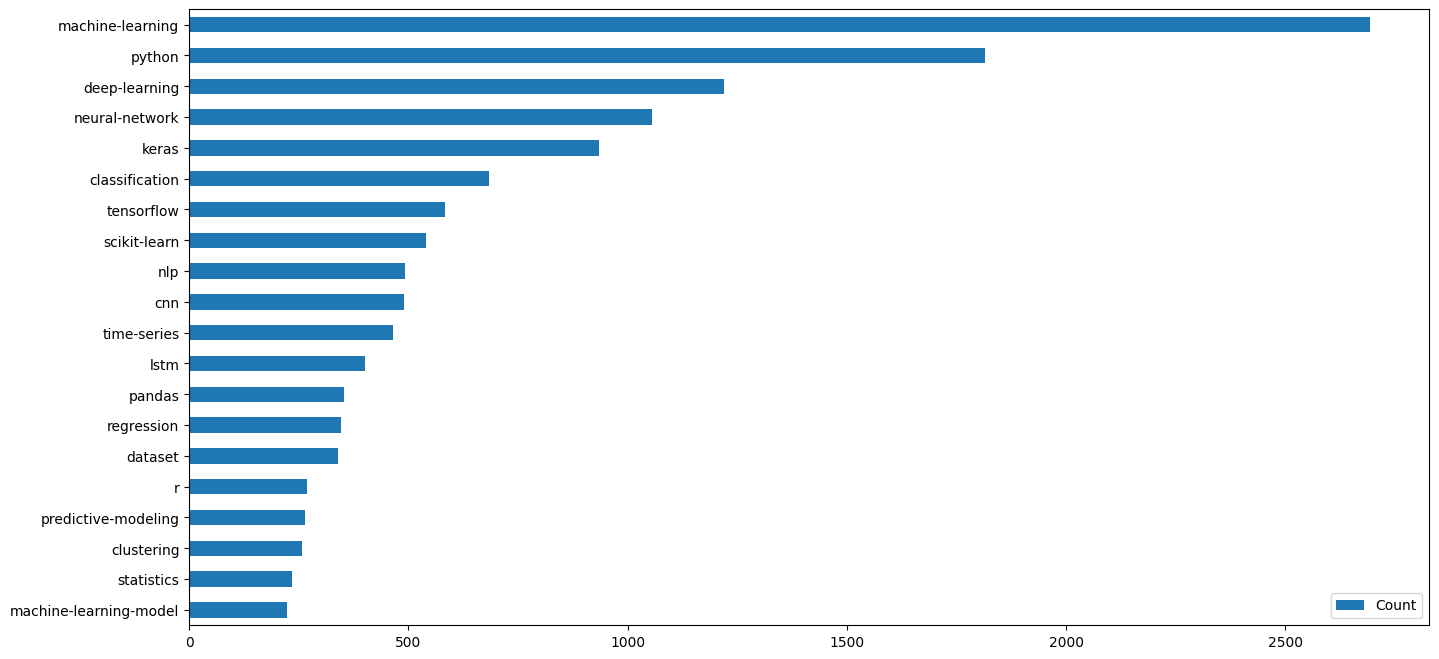

In [8]:
most_used.plot(kind='barh', figsize=(16,8))

<Axes: >

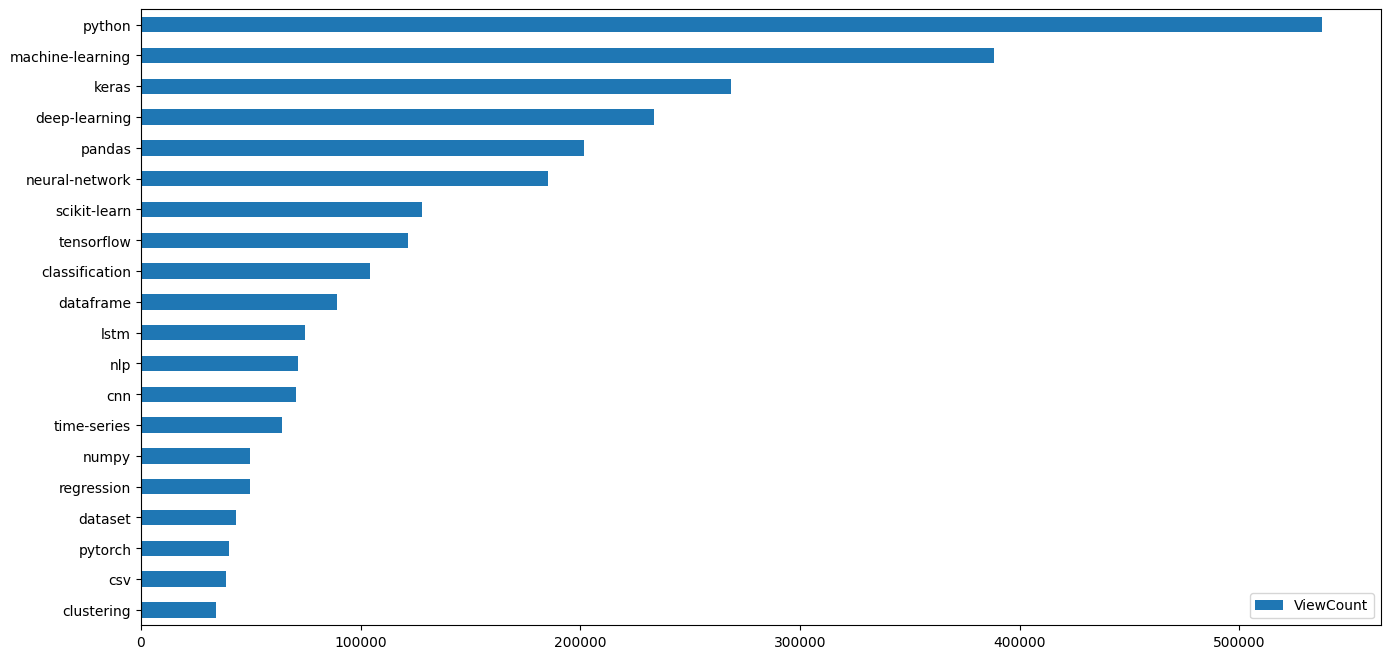

In [9]:
tag_view_count = {}

for index, row in df.iterrows():
    for tag in row['Tags']:
        if tag in tag_view_count:
            tag_view_count[tag] += row['ViewCount']
        else:
            tag_view_count[tag] = row['ViewCount']
            
tag_view_count = pd.DataFrame.from_dict(tag_view_count, orient="index")
tag_view_count.rename(columns={0: "ViewCount"}, inplace=True)

most_viewed = tag_view_count.sort_values(by="ViewCount").tail(20)

most_viewed.plot(kind="barh", figsize=(16,8))

In [10]:
most_viewed.head(50)

,ViewCount
clustering,33928
csv,38654
pytorch,40240
dataset,43151
regression,49451
numpy,49767
time-series,64134
cnn,70349
nlp,71382
lstm,74458


## Check if Just a Fad?

In [12]:
question = pd.read_csv('../../dataset/all_questions.csv', parse_dates = ['CreationDate'])
question.head()

,Id,CreationDate,Tags
0,45416,2019-02-12 00:36:29,<python><keras><tensorflow><cnn><probability>
1,45418,2019-02-12 00:50:39,<neural-network>
2,45422,2019-02-12 04:40:51,<python><ibm-watson><chatbot>
3,45426,2019-02-12 04:51:49,<keras>
4,45427,2019-02-12 05:08:24,<r><predictive-modeling><machine-learning-mode...


In [13]:
question['Tags'] = question['Tags'].str.split('><')
question['Tags'] = question['Tags'].apply(change_str)
question['Tags'].head()

0        [python, keras, tensorflow, cnn, probability]
1                                     [neural-network]
2                        [python, ibm-watson, chatbot]
3                                              [keras]
4    [r, predictive-modeling, machine-learning-mode...
Name: Tags, dtype: object